In [60]:
# ============================================================
# 1. IMPORTAZIONE DELLE LIBRERIE
# ============================================================

# pandas serve per lavorare con i dati sotto forma di DataFrame
import pandas as pd

# numpy serve per effettuare operazioni numeriche
import numpy as np

# scipy.stats contiene diversi test statistici
from scipy import stats

# statsmodels serve per i modelli statistici,
# anche se nella versione finale della regressione
# useremo principalmente scikit-learn
import statsmodels.api as sm

# LogisticRegression permette di costruire
# una regressione logistica penalizzata
from sklearn.linear_model import LogisticRegression

# train_test_split divide i dati in training set e test set
from sklearn.model_selection import train_test_split

# Queste funzioni servono per valutare
# le prestazioni del modello di classificazione
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [61]:
# ============================================================
# 2. CARICAMENTO DEL DATASET
# ============================================================


df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')
# Visualizziamo il numero di righe e colonne
# per controllare che il dataset sia stato caricato correttamente
print("Dimensioni del dataset:", df.shape)

# Visualizziamo le prime 5 righe
# per avere una prima idea della struttura dei dati
df.head()

Dimensioni del dataset: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [62]:
# ============================================================
# 3. PRIMA ESPLORAZIONE DEL DATASET
# ============================================================

# Visualizziamo i nomi di tutte le variabili
print(df.columns.tolist())

# Controlliamo il tipo di dato di ogni variabile
print(df.dtypes)

# Controlliamo quanti valori mancanti ci sono per ogni variabile
print(df.isna().sum())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [63]:
# ============================================================
# 4. PULIZIA DEL DATASET
# ============================================================

# Queste variabili non sono necessarie per le analisi
# che vogliamo effettuare.
#
# In particolare:
# - Email e password sono dati personali e non servono
# - Product Image e Product Description non sono utili
#   per la nostra analisi quantitativa
# - Order Zipcode non verrà utilizzato nell'analisi geografica
#   che abbiamo scelto di fare

colonne_da_eliminare = [
    'Customer Email',
    'Customer Password',
    'Product Image',
    'Product Description',
    'Order Zipcode'
]

# Eliminiamo le colonne dal DataFrame
df = df.drop(columns=colonne_da_eliminare)

# Controlliamo le nuove dimensioni
print("Dimensioni dopo la pulizia:", df.shape)

Dimensioni dopo la pulizia: (180519, 48)


In [64]:
# ============================================================
# 5. IDENTIFICAZIONE DELL'UNITÀ DI OSSERVAZIONE
# ============================================================

# Controlliamo quanti ordini distinti sono presenti nel dataset.
# Una stessa Order Id può infatti comparire più volte,
# perché un ordine può contenere più prodotti.
numero_ordini = df['Order Id'].nunique()

print("Numero di ordini distinti:", numero_ordini)

# Controlliamo quante righe contiene ciascun ordine.
righe_per_ordine = df.groupby('Order Id').size()

print("\nNumero minimo di righe per ordine:",
      righe_per_ordine.min())

print("Numero massimo di righe per ordine:",
      righe_per_ordine.max())

print("Numero medio di righe per ordine:",
      righe_per_ordine.mean())

print("Mediana delle righe per ordine:",
      righe_per_ordine.median())

Numero di ordini distinti: 65752

Numero minimo di righe per ordine: 1
Numero massimo di righe per ordine: 5
Numero medio di righe per ordine: 2.745452609806546
Mediana delle righe per ordine: 3.0


Il dataset originale contiene 180.519 osservazioni, ma queste non corrispondono ad altrettanti ordini. La stessa Order Id può infatti comparire più volte, poiché un singolo ordine può contenere diversi prodotti. Per questo motivo è necessario identificare l’unità statistica più appropriata per l’analisi. Nel dataset sono presenti 65.752 ordini distinti. Ogni ordine contiene mediamente circa 2,75 righe, con un minimo di una riga e un massimo di cinque. Poiché l’obiettivo principale dell’analisi è studiare le caratteristiche e le performance degli ordini e delle relative consegne, si sceglie di utilizzare l’ordine come unità di osservazione.

In [65]:
# ============================================================
# 6. CONTROLLI DI COERENZA DEGLI ORDINI
# ============================================================

# Per ogni ordine controlliamo quante modalità di spedizione
# diverse sono presenti.
shipping_mode_per_order = df.groupby('Order Id')['Shipping Mode'].nunique()

print("Ordini con più di una Shipping Mode:",
      (shipping_mode_per_order > 1).sum())


# Controlliamo quante Delivery Status diversi
# sono associati allo stesso ordine.
delivery_status_per_order = df.groupby('Order Id')['Delivery Status'].nunique()

print("Ordini con più di un Delivery Status:",
      (delivery_status_per_order > 1).sum())


# Controlliamo quante Market diversi
# sono associati allo stesso ordine.
market_per_order = df.groupby('Order Id')['Market'].nunique()

print("Ordini con più di un Market:",
      (market_per_order > 1).sum())

Ordini con più di una Shipping Mode: 0
Ordini con più di un Delivery Status: 0
Ordini con più di un Market: 0


Prima di procedere all’aggregazione a livello di ordine vengono effettuati alcuni controlli di coerenza. In particolare, si verifica che ciascun ordine sia associato a una sola modalità di spedizione, a un solo stato di consegna e a un solo mercato. I controlli non evidenziano ordini con più di una modalità di spedizione, più di uno stato di consegna o più di un mercato. Questo risultato supporta la scelta di aggregare le osservazioni al livello dell’ordine utilizzando tali variabili come caratteristiche dell’ordine.

In [66]:
# ============================================================
# 7. CREAZIONE DEL DATASET A LIVELLO DI ORDINE
# ============================================================

# Raggruppiamo tutte le righe appartenenti allo stesso ordine.
#
# Per le variabili qualitative utilizziamo il primo valore,
# dato che i controlli precedenti hanno mostrato che tali
# informazioni sono coerenti all'interno dello stesso ordine.
#
# Per Sales e Order Profit Per Order utilizziamo invece la somma,
# perché un ordine può contenere più prodotti e quindi più righe.

df_orders = df.groupby('Order Id').agg({
    'Delivery Status': 'first',
    'Shipping Mode': 'first',
    'Market': 'first',
    'Order Region': 'first',
    'Sales': 'sum',
    'Order Profit Per Order': 'sum',
    'Days for shipment (scheduled)': 'first',
    'Days for shipping (real)': 'first'
}).reset_index()

# Controlliamo le dimensioni del nuovo dataset
print("Dimensioni di df_orders:", df_orders.shape)

# Controlliamo le prime righe
df_orders.head()

Dimensioni di df_orders: (65752, 9)


,Order Id,Delivery Status,Shipping Mode,Market,Order Region,Sales,Order Profit Per Order,Days for shipment (scheduled),Days for shipping (real)
0,1,Advance shipping,Standard Class,LATAM,Central America,299.980011,88.790001,4,2
1,2,Advance shipping,Standard Class,LATAM,South America,579.980011,195.900002,4,3
2,4,Late delivery,Standard Class,LATAM,South America,699.850010,124.090000,4,5
3,5,Late delivery,Standard Class,LATAM,South America,1129.860039,390.089995,4,6
4,7,Late delivery,Second Class,LATAM,South America,579.920013,203.929998,2,3


Per rendere coerente l’unità di osservazione con gli obiettivi dell’analisi, le 180.519 righe originarie vengono aggregate per Order Id. Si ottiene così un nuovo DataFrame denominato df_orders, costituito da 65.752 ordini distinti. Le variabili categoriali vengono rappresentate attraverso il primo valore osservato, poiché i controlli precedenti hanno mostrato che sono costanti all’interno dell’ordine. Le variabili economiche Sales e Order Profit Per Order vengono invece sommate per ottenere un valore complessivo riferito all’ordine.

In [67]:
# ============================================================
# 8. ANALISI DEL DELIVERY STATUS
# ============================================================

# Calcoliamo il numero di ordini appartenenti
# a ciascuna categoria di Delivery Status.
conteggio_delivery = df_orders['Delivery Status'].value_counts()

print(conteggio_delivery)


# Calcoliamo anche le percentuali.
percentuale_delivery = (
    df_orders['Delivery Status']
    .value_counts(normalize=True)
    * 100
)

print("\nPercentuali:")
print(percentuale_delivery.round(2))

Delivery Status
Late delivery        36048
Advance shipping     15127
Shipping on time     11722
Shipping canceled     2855
Name: count, dtype: int64

Percentuali:
Delivery Status
Late delivery        54.82
Advance shipping     23.01
Shipping on time     17.83
Shipping canceled     4.34
Name: proportion, dtype: float64


Viene analizzata la distribuzione degli ordini rispetto allo stato di consegna. La categoria più frequente è Late delivery, che rappresenta circa il 54,82% degli ordini. Seguono Advance shipping, pari a circa il 23,01%, Shipping on time, pari al 17,83%, e infine Shipping canceled, che rappresenta circa il 4,34%. La presenza di una quota così elevata di consegne classificate come tardive evidenzia un possibile problema operativo che merita di essere approfondito attraverso l’analisi della modalità di spedizione e delle caratteristiche geografiche.

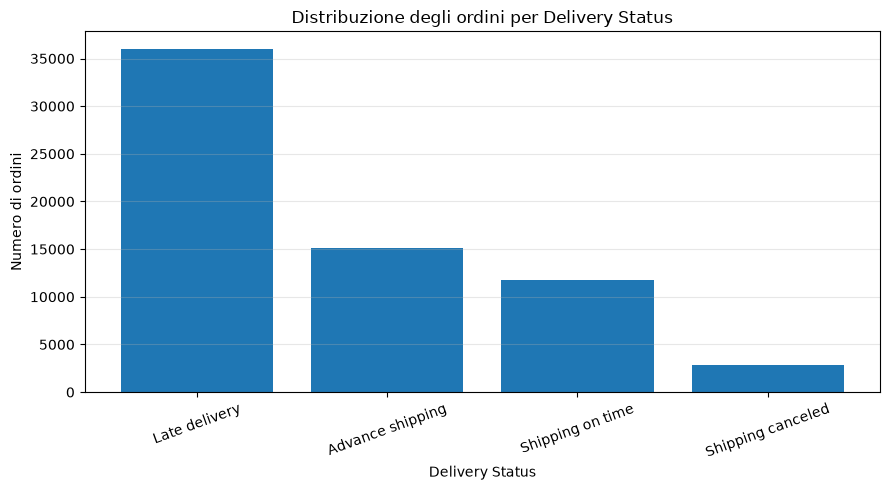

In [68]:
# ============================================================
#GRAFICO DEL DELIVERY STATUS
# ============================================================

import matplotlib.pyplot as plt

# Calcoliamo il numero di ordini per ogni Delivery Status
conteggio_delivery = (
    df_orders['Delivery Status']
    .value_counts()
)

# Creiamo il grafico a barre
plt.figure(figsize=(9, 5))

plt.bar(
    conteggio_delivery.index,
    conteggio_delivery.values
)

# Titolo del grafico
plt.title('Distribuzione degli ordini per Delivery Status')

# Etichette degli assi
plt.xlabel('Delivery Status')
plt.ylabel('Numero di ordini')

# Ruotiamo le etichette dell'asse X
# per renderle più leggibili
plt.xticks(rotation=20)

# Aggiungiamo una griglia orizzontale
plt.grid(axis='y', alpha=0.3)

# Sistemiamo automaticamente gli spazi
plt.tight_layout()

# Mostriamo il grafico
plt.show()

Il grafico mostra la distribuzione degli ordini nelle diverse categorie di stato della consegna. La categoria Late delivery risulta nettamente predominante, rappresentando più della metà degli ordini complessivi. Il grafico permette quindi di evidenziare immediatamente la rilevanza del problema delle consegne tardive all’interno del dataset.

In [69]:
# ============================================================
# 9. SHIPPING MODE × DELIVERY STATUS
# ============================================================

# Creiamo una tabella di contingenza.
# Le righe rappresentano la modalità di spedizione,
# mentre le colonne rappresentano lo stato della consegna.

tabella_shipping_delivery = pd.crosstab(
    df_orders['Shipping Mode'],
    df_orders['Delivery Status']
)

print(tabella_shipping_delivery)

Delivery Status  Advance shipping  Late delivery  Shipping canceled  \
Shipping Mode                                                         
First Class                     0           9602                477   
Same Day                        0           1648                164   
Second Class                    0           9803                522   
Standard Class              15127          14995               1692   

Delivery Status  Shipping on time  
Shipping Mode                      
First Class                     0  
Same Day                     1759  
Second Class                 2453  
Standard Class               7510  


Per approfondire la relazione tra modalità di spedizione e risultato della consegna viene costruita una tabella di contingenza. Le righe rappresentano le diverse modalità di spedizione, mentre le colonne rappresentano gli stati di consegna. La tabella permette di osservare differenze molto marcate tra le modalità. In particolare, First Class presenta una quota molto elevata di consegne tardive, mentre Same Day presenta una quota relativamente elevata di consegne effettuate nei tempi previsti. Standard Class presenta invece sia ordini classificati come Advance shipping sia ordini classificati come Late delivery.

In [70]:
# ============================================================
# 10. PERCENTUALI PER SHIPPING MODE
# ============================================================

# Normalizziamo ogni riga della tabella in modo che
# la somma delle percentuali all'interno di ogni Shipping Mode
# sia pari al 100%.

percentuali_shipping_delivery = pd.crosstab(
    df_orders['Shipping Mode'],
    df_orders['Delivery Status'],
    normalize='index'
) * 100

print(percentuali_shipping_delivery.round(2))

Delivery Status  Advance shipping  Late delivery  Shipping canceled  \
Shipping Mode                                                         
First Class                  0.00          95.27               4.73   
Same Day                     0.00          46.15               4.59   
Second Class                 0.00          76.72               4.09   
Standard Class              38.47          38.13               4.30   

Delivery Status  Shipping on time  
Shipping Mode                      
First Class                  0.00  
Same Day                    49.26  
Second Class                19.20  
Standard Class              19.10  


Per confrontare le modalità di spedizione indipendentemente dalla loro numerosità viene calcolata la distribuzione percentuale degli stati di consegna all’interno di ciascuna modalità. I risultati mostrano differenze importanti. First Class presenta circa il 95,27% di ordini in ritardo, mentre Same Day presenta circa il 49,26% di consegne nei tempi previsti e il 46,15% di consegne tardive. Second Class presenta circa il 76,72% di consegne tardive. Standard Class presenta invece una distribuzione più equilibrata, con circa il 38,47% di ordini classificati come Advance shipping, il 38,13% come Late delivery e il 19,10% come Shipping on time.

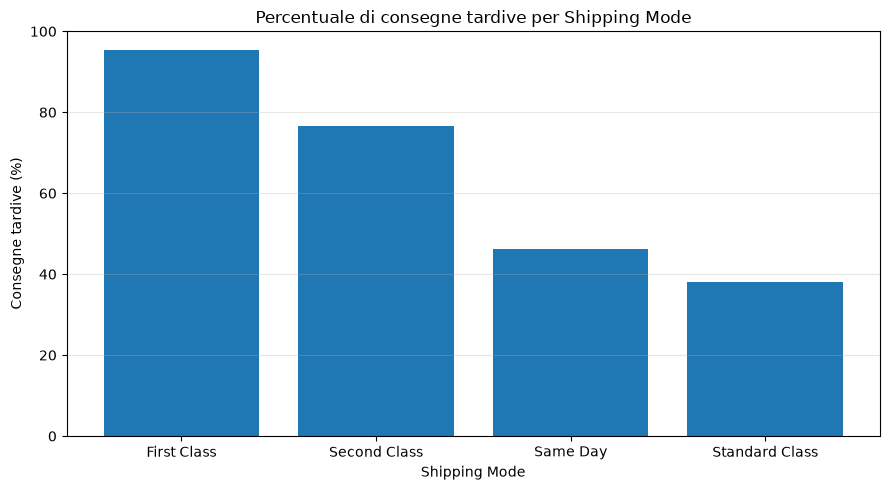

In [71]:
# ============================================================
#TASSO DI RITARDO PER SHIPPING MODE
# ============================================================

# Calcoliamo la percentuale di ordini in ritardo
# all'interno di ogni modalità di spedizione.

late_rate_shipping = (
    df_orders
    .groupby('Shipping Mode')['Delivery Status']
    .apply(
        lambda x: (x == 'Late delivery').mean() * 100
    )
    .sort_values(ascending=False)
)

# Creiamo il grafico
plt.figure(figsize=(9, 5))

plt.bar(
    late_rate_shipping.index,
    late_rate_shipping.values
)

# Titolo
plt.title('Percentuale di consegne tardive per Shipping Mode')

# Etichette degli assi
plt.xlabel('Shipping Mode')
plt.ylabel('Consegne tardive (%)')

# Impostiamo il limite dell'asse Y
# perché stiamo rappresentando una percentuale
plt.ylim(0, 100)

# Griglia orizzontale
plt.grid(axis='y', alpha=0.3)

# Sistemiamo il grafico
plt.tight_layout()

# Mostriamo il grafico
plt.show()

Il grafico confronta la percentuale di consegne tardive tra le diverse modalità di spedizione. Emergono differenze molto marcate: First Class presenta una percentuale di ritardi superiore al 95%, Second Class supera il 75%, mentre Standard Class presenta una percentuale inferiore al 40%. Same Day presenta una percentuale di ritardi di circa il 46%. Il grafico rende immediatamente evidente la forte associazione tra modalità di spedizione e risultato della consegna, già confermata dal test Chi-quadrato e dal valore di Cramér’s V.

In [72]:
# ============================================================
# 11. TEST CHI-QUADRATO DI INDIPENDENZA
# ============================================================

# Eseguiamo il test Chi-quadrato sulla tabella di contingenza.
chi2, p_value, gradi_liberta, frequenze_attese = stats.chi2_contingency(
    tabella_shipping_delivery
)

print("Chi-quadrato:", chi2)
print("Gradi di libertà:", gradi_liberta)
print("p-value:", p_value)

Chi-quadrato: 20168.767960919387
Gradi di libertà: 9
p-value: 0.0


Per verificare formalmente l’esistenza di un’associazione tra Shipping Mode e Delivery Status viene applicato il test Chi-quadrato di indipendenza. L’ipotesi nulla del test afferma che le due variabili siano indipendenti. Il test produce un valore di Chi-quadrato pari a 20.168,77 con 9 gradi di libertà e un p-value inferiore a 0,001. Si rifiuta quindi l’ipotesi nulla di indipendenza. Esiste pertanto un’associazione statisticamente significativa tra la modalità di spedizione e lo stato della consegna.

In [73]:
# ============================================================
# 12. CRAMÉR'S V
# ============================================================

# Calcoliamo il numero totale di osservazioni.
n = tabella_shipping_delivery.to_numpy().sum()

# Calcoliamo il numero minimo tra:
# numero di righe e numero di colonne.
min_dimensione = min(
    tabella_shipping_delivery.shape
) - 1

# Calcoliamo Cramér's V.
cramers_v = np.sqrt(
    chi2 / (n * min_dimensione)
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.3197603227968713


Per valutare la forza dell’associazione viene utilizzato l’indice Cramér’s V. Il valore ottenuto è circa 0,320, indicando un’associazione di entità moderata tra modalità di spedizione e stato della consegna. Pertanto, la relazione osservata non è soltanto statisticamente significativa, ma presenta anche una rilevanza non trascurabile dal punto di vista descrittivo. Il risultato non implica tuttavia un rapporto causale tra le due variabili.

In [74]:
# ============================================================
# 13. IMPATTO ECONOMICO DEL DELIVERY STATUS
# ============================================================

# Calcoliamo Sales e Profitto medio per ciascun Delivery Status.

impatto_economico = (
    df_orders
    .groupby('Delivery Status')[[
        'Sales',
        'Order Profit Per Order'
    ]]
    .mean()
)

print(impatto_economico.round(2))

                    Sales  Order Profit Per Order
Delivery Status                                  
Advance shipping   563.10                   61.82
Late delivery      558.32                   59.37
Shipping canceled  550.02                   56.21
Shipping on time   560.49                   62.37


Per valutare se lo stato della consegna sia associato a differenze nelle performance economiche degli ordini vengono confrontati i valori medi di Sales e Order Profit Per Order tra le diverse categorie di Delivery Status. I risultati mostrano differenze contenute nei valori medi di vendita e profitto tra le categorie. In particolare, gli ordini Shipping on time presentano un profitto medio di circa 62,37 dollari, mentre quelli Late delivery presentano un profitto medio di circa 59,37 dollari. Queste differenze vengono successivamente sottoposte a un test statistico.

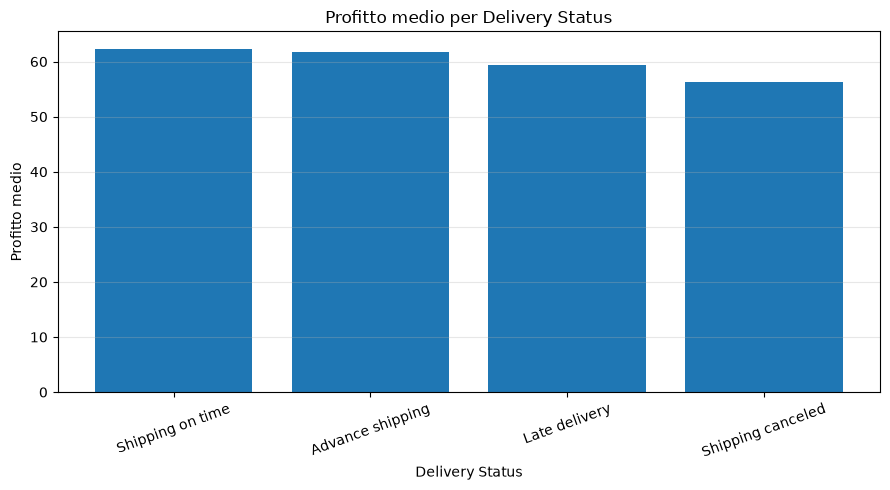

In [75]:
# ============================================================
#PROFITTO MEDIO PER DELIVERY STATUS
# ============================================================

# Calcoliamo il profitto medio per ciascun Delivery Status
profitto_medio = (
    df_orders
    .groupby('Delivery Status')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

# Creiamo il grafico
plt.figure(figsize=(9, 5))

plt.bar(
    profitto_medio.index,
    profitto_medio.values
)

# Titolo
plt.title('Profitto medio per Delivery Status')

# Etichette degli assi
plt.xlabel('Delivery Status')
plt.ylabel('Profitto medio')

# Ruotiamo leggermente le etichette
plt.xticks(rotation=20)

# Griglia
plt.grid(axis='y', alpha=0.3)

# Sistemiamo gli spazi
plt.tight_layout()

# Mostriamo il grafico
plt.show()

Il grafico confronta il profitto medio degli ordini appartenenti ai diversi stati di consegna. Le differenze osservate sono relativamente contenute: gli ordini consegnati nei tempi previsti presentano un profitto medio leggermente superiore rispetto agli ordini consegnati in ritardo. Tuttavia, come evidenziato dal Welch t-test, la differenza tra Late delivery e Shipping on time non risulta statisticamente significativa al livello del 5%.

In [76]:
# ============================================================
# 14. WELCH T-TEST
# ============================================================

# Selezioniamo il profitto degli ordini consegnati in ritardo.
profit_late = df_orders.loc[
    df_orders['Delivery Status'] == 'Late delivery',
    'Order Profit Per Order'
]

# Selezioniamo il profitto degli ordini consegnati nei tempi previsti.
profit_on_time = df_orders.loc[
    df_orders['Delivery Status'] == 'Shipping on time',
    'Order Profit Per Order'
]

# Eseguiamo il Welch t-test.
# Viene utilizzato equal_var=False perché non assumiamo
# che le varianze dei due gruppi siano uguali.

t_stat, p_value_ttest = stats.ttest_ind(
    profit_late,
    profit_on_time,
    equal_var=False
)

print("Media profitto - Late delivery:",
      profit_late.mean())

print("Media profitto - Shipping on time:",
      profit_on_time.mean())

print("Differenza tra le medie:",
      profit_late.mean() - profit_on_time.mean())

print("t-statistic:", t_stat)

print("p-value:", p_value_ttest)

Media profitto - Late delivery: 59.36672441457976
Media profitto - Shipping on time: 62.37362830904103
Differenza tra le medie: -3.0069038944612743
t-statistic: -1.492555955437592
p-value: 0.13556912285774025


Per verificare se il profitto medio differisca significativamente tra ordini consegnati in ritardo e ordini consegnati nei tempi previsti viene applicato il Welch t-test. Il profitto medio è pari a circa 59,37 dollari per gli ordini Late delivery e 62,37 dollari per gli ordini Shipping on time, con una differenza di circa -3,01 dollari. Il test restituisce un p-value pari a circa 0,136, superiore alla soglia convenzionale del 5%. Non si dispone quindi di evidenza statistica sufficiente per affermare che il profitto medio differisca significativamente tra i due gruppi.

In [77]:
# ============================================================
# 15. ANALISI DEI TEMPI DI SPEDIZIONE
# ============================================================

# Calcoliamo la differenza tra i giorni effettivi
# necessari alla spedizione e quelli programmati.

df_orders['Delay_Days'] = (
    df_orders['Days for shipping (real)']
    -
    df_orders['Days for shipment (scheduled)']
)

# Calcoliamo la media dei tempi programmati,
# dei tempi effettivi e del ritardo per ogni Shipping Mode.

tempi_spedizione = (
    df_orders
    .groupby('Shipping Mode')[[
        'Days for shipment (scheduled)',
        'Days for shipping (real)',
        'Delay_Days'
    ]]
    .mean()
)

print(tempi_spedizione.round(2))

                Days for shipment (scheduled)  Days for shipping (real)  \
Shipping Mode                                                             
First Class                               1.0                      2.00   
Same Day                                  0.0                      0.48   
Second Class                              2.0                      4.00   
Standard Class                            4.0                      4.00   

                Delay_Days  
Shipping Mode               
First Class           1.00  
Same Day              0.48  
Second Class          2.00  
Standard Class       -0.00  


Per analizzare le performance temporali delle diverse modalità di spedizione viene costruita la variabile Delay_Days, ottenuta come differenza tra i giorni effettivamente necessari alla spedizione e quelli programmati. I risultati mostrano differenze tra le modalità. First Class presenta mediamente un ritardo di circa un giorno, Same Day di circa 0,48 giorni, mentre Second Class presenta un ritardo medio di circa due giorni. Standard Class presenta invece un valore medio prossimo allo zero. Questa analisi deve essere interpretata come descrittiva, poiché lo stato di consegna è costruito proprio sulla relazione tra tempi previsti e tempi effettivi.

In [78]:
# ============================================================
# 16. ANALISI GEOGRAFICA DI FIRST CLASS
# ============================================================

# Selezioniamo solamente gli ordini effettuati
# tramite la modalità First Class.

df_first_class = df_orders[
    df_orders['Shipping Mode'] == 'First Class'
].copy()

# Calcoliamo la percentuale di consegne tardive
# per ciascuna Order Region.

ritardo_first_class = (
    df_first_class
    .groupby('Order Region')['Delivery Status']
    .apply(
        lambda x: (x == 'Late delivery').mean() * 100
    )
    .sort_values(ascending=False)
)

print(ritardo_first_class.round(2))

Order Region
Central Asia       100.00
Southern Africa     98.46
East Africa         97.92
North Africa        96.77
Southern Europe     96.57
South Asia          96.32
West Asia           96.05
West Africa         95.86
Northern Europe     95.83
East of USA         95.80
US Center           95.73
Central America     95.44
Western Europe      95.35
Southeast Asia      95.31
Eastern Europe      95.28
Oceania             94.97
South of  USA       94.92
West of USA         94.47
Caribbean           94.46
Eastern Asia        93.99
South America       93.42
Central Africa      92.71
Canada              91.38
Name: Delivery Status, dtype: float64


Poiché First Class presenta una percentuale particolarmente elevata di consegne tardive, viene effettuata un’analisi geografica specifica. Gli ordini First Class vengono raggruppati per Order Region e, per ciascuna regione, viene calcolata la percentuale di ordini classificati come Late delivery. I risultati mostrano percentuali molto elevate in tutte le regioni considerate, generalmente superiori al 90%. L’analisi suggerisce quindi che il comportamento problematico di First Class non sia limitato a una singola area geografica. Tuttavia, le differenze tra regioni devono essere interpretate con cautela, soprattutto considerando la diversa numerosità degli ordini presenti in ciascuna regione.

In [79]:
# ============================================================
# 17. PREPARAZIONE DELLA REGRESSIONE LOGISTICA
# ============================================================

# Escludiamo gli ordini cancellati.
# Non vogliamo infatti prevedere il ritardo per ordini
# che non sono arrivati a una fase normale di consegna.

df_model = df_orders[
    df_orders['Delivery Status'] != 'Shipping canceled'
].copy()

# Creiamo la variabile risposta binaria:
#
# 1 = Late delivery
# 0 = qualsiasi altro stato di consegna non cancellato

df_model['Is_Late'] = (
    df_model['Delivery Status'] == 'Late delivery'
).astype(int)

# Controlliamo la distribuzione della variabile risposta.
print(df_model['Is_Late'].value_counts())

print(
    df_model['Is_Late']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Is_Late
1    36048
0    26849
Name: count, dtype: int64
Is_Late
1    57.31
0    42.69
Name: proportion, dtype: float64


Per costruire un modello di regressione logistica viene definita una variabile binaria Is_Late, che assume valore 1 per gli ordini classificati come Late delivery e valore 0 per gli altri ordini non cancellati. Gli ordini Shipping canceled vengono esclusi poiché non rappresentano consegne completate e quindi non sono direttamente confrontabili con gli altri ordini. La variabile risposta permette di trasformare il problema in una classificazione binaria: prevedere se un ordine sarà consegnato in ritardo oppure no.

In [80]:
# ============================================================
# 18. PREPARAZIONE DELLE VARIABILI ESPLICATIVE
# ============================================================

# Variabili qualitative che vogliamo utilizzare
# come predittori del ritardo.

variabili_categoriche = [
    'Shipping Mode',
    'Market',
    'Order Region'
]

# Trasformiamo le variabili categoriche in variabili dummy.
#
# drop_first=True elimina una categoria di riferimento
# per evitare una perfetta multicollinearità.

X_categoriche = pd.get_dummies(
    df_model[variabili_categoriche],
    drop_first=True,
    dtype=float
)

# Variabile numerica:
# numero di giorni programmati per la spedizione.

variabili_numeriche = [
    'Days for shipment (scheduled)'
]

# Uniamo variabili categoriche e numeriche
# per creare la matrice finale dei predittori.

X = pd.concat(
    [
        X_categoriche,
        df_model[variabili_numeriche]
    ],
    axis=1
)

# La variabile risposta è Is_Late.
y = df_model['Is_Late']

print("Dimensioni di X:", X.shape)
print("Dimensioni di y:", y.shape)

Dimensioni di X: (62897, 30)
Dimensioni di y: (62897,)


Le variabili categoriche Shipping Mode, Market e Order Region vengono trasformate in variabili dummy, in modo da poter essere utilizzate all’interno della regressione logistica. Una categoria per ciascuna variabile viene utilizzata come categoria di riferimento. Viene inoltre inclusa la variabile numerica relativa ai giorni di spedizione programmati. La matrice finale X contiene quindi le variabili esplicative, mentre y rappresenta la variabile risposta binaria Is_Late.

In [81]:
# ============================================================
# 19. TRAINING SET E TEST SET
# ============================================================

# Dividiamo i dati in:
# - 80% training set
# - 20% test set
#
# random_state=42 rende il risultato riproducibile.
#
# stratify=y mantiene nel training e nel test
# la stessa proporzione di ordini in ritardo e non in ritardo.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (50317, 30)
Test set: (12580, 30)


Per valutare la capacità predittiva del modello, il dataset viene suddiviso in un training set, contenente l’80% delle osservazioni, e in un test set, contenente il restante 20%. Il modello viene stimato esclusivamente sul training set e successivamente valutato su dati non utilizzati durante la fase di addestramento. L’opzione stratify=y mantiene nei due campioni una proporzione simile di ordini in ritardo e non in ritardo, mentre random_state=42 garantisce la riproducibilità della suddivisione.

In [82]:
# ============================================================
# 20. REGRESSIONE LOGISTICA PENALIZZATA
# ============================================================

# Creiamo il modello di regressione logistica.
#
# La penalizzazione L2 aiuta a gestire problemi di
# separazione quasi perfetta presenti nei dati.
#
# C=1.0 controlla la forza della regolarizzazione.
#
# max_iter indica il numero massimo di iterazioni
# consentite all'algoritmo per trovare la soluzione.

modello_logit = LogisticRegression(
    C=1.0,
    max_iter=1000
)

# Stimiamo il modello utilizzando solamente
# il training set.

modello_logit.fit(X_train, y_train)

print("Modello stimato correttamente.")

Modello stimato correttamente.


Viene stimata una regressione logistica penalizzata tramite regolarizzazione L2. La scelta della penalizzazione è particolarmente importante in questo dataset perché alcune modalità di spedizione presentano una separazione molto forte rispetto alla variabile di risposta. In particolare, First Class presenta una percentuale estremamente elevata di consegne tardive. La regolarizzazione permette di ottenere stime più stabili rispetto a una regressione logistica standard. Il modello deve essere interpretato principalmente come strumento predittivo e non come prova di causalità.

In [83]:
# ============================================================
# 21. PREDIZIONI SUL TEST SET
# ============================================================

# Predizione della classe:
# 0 = non in ritardo
# 1 = in ritardo

y_pred = modello_logit.predict(X_test)

# Probabilità stimata che l'ordine sia in ritardo.

y_prob = modello_logit.predict_proba(X_test)[:, 1]

print("Prime 10 classi predette:")
print(y_pred[:10])

print("\nPrime 10 probabilità di ritardo:")
print(y_prob[:10])

Prime 10 classi predette:
[1 0 0 1 0 0 0 0 1 1]

Prime 10 probabilità di ritardo:
[0.99800866 0.38301331 0.34647347 0.99801497 0.40392797 0.39550989
 0.39916656 0.39550989 0.99801497 0.99815179]


Dopo la stima del modello vengono effettuate le predizioni sul test set. Per ogni ordine il modello produce sia una classificazione binaria, indicando se l’ordine viene previsto come tardivo o non tardivo, sia una probabilità stimata di appartenenza alla categoria Late delivery. L’utilizzo delle probabilità permette di valutare il modello anche attraverso metriche indipendenti dalla soglia di classificazione, come la ROC-AUC.

In [84]:
# ============================================================
# 22. VALUTAZIONE DEL MODELLO
# ============================================================

# Calcoliamo l'accuracy:
# proporzione di classificazioni corrette.

accuracy = accuracy_score(
    y_test,
    y_pred
)

# Calcoliamo la ROC-AUC:
# misura la capacità del modello di distinguere
# tra ordini in ritardo e non in ritardo.

auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy:", round(accuracy, 3))
print("ROC-AUC:", round(auc, 3))

# Stampiamo precision, recall e F1-score
# separatamente per le due classi.

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# Creiamo la matrice di confusione.

matrice_confusione = confusion_matrix(
    y_test,
    y_pred
)

print("\nMatrice di confusione:")
print(matrice_confusione)

Accuracy: 0.693
ROC-AUC: 0.741

Classification report:
              precision    recall  f1-score   support

           0       0.59      0.90      0.71      5370
           1       0.88      0.54      0.67      7210

    accuracy                           0.69     12580
   macro avg       0.73      0.72      0.69     12580
weighted avg       0.75      0.69      0.69     12580


Matrice di confusione:
[[4813  557]
 [3309 3901]]


Il modello viene valutato sul test set attraverso diverse metriche. L’accuracy misura la proporzione complessiva di classificazioni corrette, mentre la ROC-AUC valuta la capacità del modello di distinguere tra ordini in ritardo e non in ritardo considerando le probabilità stimate. Nel nostro caso il modello raggiunge un’accuracy di circa 0,693 e una ROC-AUC di circa 0,741. Il valore della ROC-AUC indica una capacità discriminante discreta e superiore a quella di un classificatore casuale, mentre l’accuracy deve essere interpretata insieme a precision, recall e F1-score a causa della distribuzione non perfettamente bilanciata delle due classi.

In [85]:
# ============================================================
# 23. COEFFICIENTI E ODDS RATIO
# ============================================================

# Estraiamo i coefficienti stimati dal modello.

coefficienti = pd.Series(
    modello_logit.coef_[0],
    index=X.columns
)

# Convertiamo i coefficienti logit in Odds Ratio.
#
# exp(coefficiente) > 1
# --> aumento degli odds dell'evento
#
# exp(coefficiente) < 1
# --> diminuzione degli odds dell'evento

odds_ratio = np.exp(coefficienti)

# Creiamo una tabella riassuntiva.

risultati_logit = pd.DataFrame({
    'Coefficiente': coefficienti,
    'Odds Ratio': odds_ratio
})

# Ordiniamo le variabili in base all'Odds Ratio.

risultati_logit = (
    risultati_logit
    .sort_values(
        'Odds Ratio',
        ascending=False
    )
)

print(risultati_logit)

                               Coefficiente  Odds Ratio
Order Region_East Africa           0.923589    2.518312
Order Region_Central Africa        0.914233    2.494860
Order Region_North Africa          0.734464    2.084364
Order Region_Southern Africa       0.696728    2.007174
Order Region_West Africa           0.674991    1.964015
Market_Pacific Asia                0.657570    1.930097
Market_Europe                      0.599890    1.821919
Market_LATAM                       0.551571    1.735978
Market_USCA                        0.544721    1.724127
Order Region_South of  USA         0.271094    1.311398
Order Region_East of USA           0.249488    1.283369
Order Region_Western Europe        0.216376    1.241569
Order Region_South America         0.206483    1.229347
Order Region_Central America       0.203517    1.225706
Order Region_West of USA           0.196814    1.217517
Order Region_US Center             0.193054    1.212948
Order Region_Eastern Europe        0.144823    1

Per interpretare il modello vengono estratti i coefficienti della regressione logistica e trasformati in Odds Ratio. Un Odds Ratio superiore a 1 indica che, a parità delle altre variabili incluse nel modello, la presenza della relativa categoria è associata a odds più elevate dell’evento Late delivery; un valore inferiore a 1 indica invece odds più basse rispetto alla categoria di riferimento. Nel caso specifico, tuttavia, gli Odds Ratio devono essere interpretati con particolare cautela perché alcune variabili, come Shipping Mode e Days for shipment (scheduled), sono fortemente correlate per costruzione. Il modello viene quindi utilizzato principalmente per valutare la capacità predittiva e individuare pattern, evitando interpretazioni causali dei singoli coefficienti.

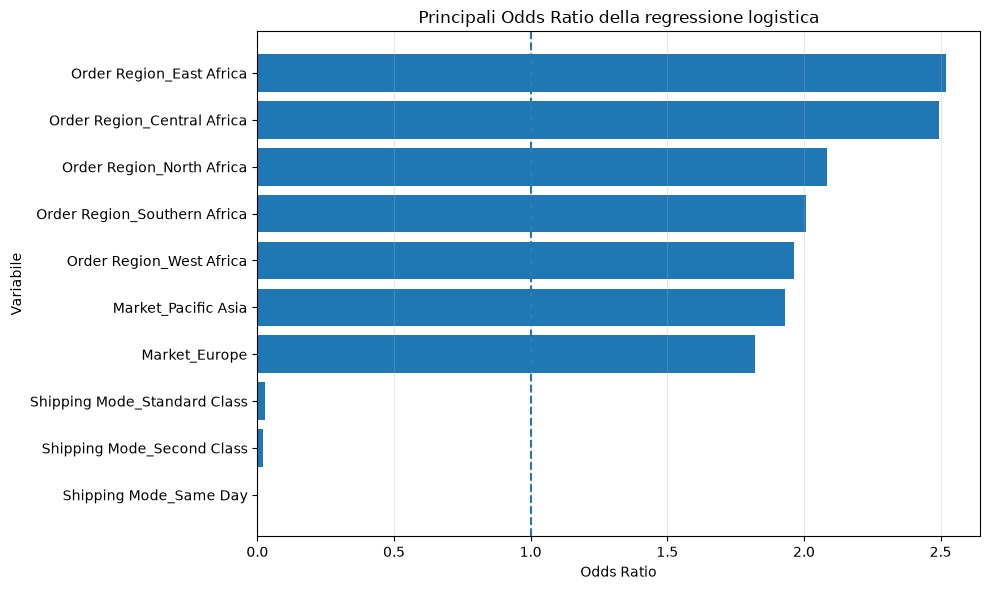

In [86]:
# ============================================================
# GRAFICO DEGLI ODDS RATIO
# ============================================================

# Calcoliamo quanto ciascun Odds Ratio è distante da 1.
#
# Un valore pari a 1 indica assenza di associazione
# rispetto alla categoria di riferimento.

risultati_logit['Distanza_da_1'] = abs(
    risultati_logit['Odds Ratio'] - 1
)

# Selezioniamo le 10 variabili con gli Odds Ratio
# più lontani da 1.

top_odds_ratio = (
    risultati_logit
    .sort_values(
        'Distanza_da_1',
        ascending=False
    )
    .head(10)
    .sort_values(
        'Odds Ratio'
    )
)

# Creiamo il grafico orizzontale
plt.figure(figsize=(10, 6))

plt.barh(
    top_odds_ratio.index,
    top_odds_ratio['Odds Ratio']
)

# Linea verticale in corrispondenza di OR = 1
plt.axvline(
    1,
    linestyle='--'
)

# Titolo
plt.title('Principali Odds Ratio della regressione logistica')

# Etichette
plt.xlabel('Odds Ratio')
plt.ylabel('Variabile')

# Griglia verticale
plt.grid(
    axis='x',
    alpha=0.3
)

# Sistemiamo gli spazi
plt.tight_layout()

# Mostriamo il grafico
plt.show()

Il grafico rappresenta le variabili con gli Odds Ratio più lontani dal valore di riferimento pari a 1. Valori superiori a 1 indicano odds stimate più elevate dell’evento Late delivery, mentre valori inferiori a 1 indicano odds stimate più basse rispetto alla categoria di riferimento. Gli Odds Ratio relativi alle modalità di spedizione risultano particolarmente estremi, coerentemente con la forte associazione osservata nei dati. Questi risultati devono tuttavia essere interpretati con cautela, poiché il modello è penalizzato e alcune variabili, in particolare Shipping Mode e Days for shipment (scheduled), sono fortemente correlate.